# Dilema do botão: uma simulação probabilística com análise gráfica e interface interativa

## 1. Introdução

A ideia do projeto é simular o dilema dos botões vermelho e azul, que consiste no seguinte cenário: dado um grupo de pessoas e dois botões disponíveis (vermelho e azul) cada indivíduo deve escolher apenas um deles. Caso mais de 50% das pessoas escolham o botão azul, todos sobrevivem. Caso contrário, todos morrem, exceto aqueles que escolheram o botão vermelho.

A partir desse problema base, será construída uma simulação de decisões fundamentada em probabilidades, a partir do qual será modelada uma curva de comportamento médio de uma determinada população com diferentes probabilidades de escolher o botão azul, tendo em vista que a decisão a nível individual é secreta. Isso é relevante, pois uma decisão não altera o efeito das demais, ou seja, são decisões independentes.

Posteriormente, os resultados dessa simulação serão analisados por meio de gráficos, com o objetivo de observar como diferentes parâmetros (como probabilidade de escolha e tamanho da população) influenciam o comportamento do sistema. 

Além da simulação com modelo matemático, o projeto também incluirá uma interface gráfica interativa feita com a biblioteca Tkinter, para que o usuário possa participar diretamente do dilema, escolhendo entre os botões vermelho e azul em tempo real, e vendo ao final de todos os votos se sobreviveu ou não.

## 2. Simulação probabilística

Nessa primeira parte, cada população será representada por um conjunto (n) de pessoas. Dentro desse conjunto, todas as pessoas terão uma mesma probabilidade de escolher o botão azul (e, consequentemente, o vermelho).

Para cada probabilidade entre 0 e 1, com intervalo de 0.01, será rodada 1000 vezes a simulação, para efeito de convergência à média, e os resultados serão analisados em 2 gráficos. Um deles medirá a taxa de sucesso coletivo da população para cada probabilidade, o sucesso coletivo significando que todos sobreviveram (ou seja, mais da metade escolheu azul). O outro, a taxa de sobrevivência média por probabilidade.

O número da população também é variável, o que altera o comportamento das curvas nos gráficos.

### 2.1 Importando bibliotecas

Será necessário importar algumas bibliotecas para o andamento do projeto: random, para a geração de números aleatórios que representam as probabilidades individuais das pessoas escolherem o botão azul; `matplotlib.pyplot`, para plotar gráficos; `numpy`, para a organização visual dos gráficos; `tkinter`, para a interface gráfica, no item 3.

In [1]:
import random as rd
import matplotlib.pyplot as mpl
import numpy as np
import tkinter as tk

### 2.2 Definindo variáveis globais

Primeiro, foi necessário definir uma variável global do tipo dicionário, chamada `dicionario_de_pessoas`, que associa cada pessoa a uma probabilidade.

In [2]:
dicionario_de_pessoas = {
    f"p{i}": 0.5 for i in range(100)
}

### 2.3 Criando a função escolha_botao

Em seguida, foi preciso criar a função `escolha_botao` para atribuir cada pessoa a uma escolha entre o botão azul e o vermelho. Ela tem como entrada a variável global `dicionario_de_pessoas`, e como saída duas listas e um novo dicionário: `botao_azul`, `botao_vermelho` e `probabilidades`.

As listas devem associar as pessoas aos botões que elas apertaram de acordo com o seguinte critério: se a sua probabilidade individual for maior que o número sorteado, ela deverá apertar o botão azul, e ser adicionada à lista `botao_azul`. O contrário para a lista `botao_vermelho`.

In [3]:
def escolha_botao(dicionario_de_pessoas):
    """
    Para cada pessoa no dicionário, sorteia a escolha entre botão azul
    ou vermelho com base na probabilidade associada. 
    Entrada: 
        - um dicionário contendo as pessoas e suas probabilidades.
    Retorno:
        - botao_azul: lista de pessoas que escolheram azul;
        - botao_vermelho: lista de pessoas que escolheram vermelho;
        - probabilidades: dicionário {pessoa: probabilidade}.
    """

    botao_azul = []
    botao_vermelho = []
    probabilidades = {}

    for pessoa in dicionario_de_pessoas:
        probabilidade = dicionario_de_pessoas[pessoa]
        probabilidades[pessoa] = probabilidade
        numero = rd.random()
        
        if numero < probabilidade:
            botao_azul.append(pessoa)
        else:
            botao_vermelho.append(pessoa)

    return botao_azul, botao_vermelho, probabilidades

### 2.4 Armazenamento em variáveis

Foram armazenados os retornos da função `escolha_botao` nas variáveis `azul`, `vermelho` e `probs`, para que elas existam fora do escopo da função.

In [4]:
azul, vermelho, probs = escolha_botao(dicionario_de_pessoas)

### 2.5 Criando a função avaliacao_botao

Na sequência, foi criada a função `avaliacao_botao`, responsável por avaliar o resultado coletivo da simulação a partir das escolhas feitas pelas pessoas entre os botões azul e vermelho. Ela recebe como entrada duas listas, azul e vermelho, que são as variáveis criadas anteriormente, que representam as pessoas que escolheram cada botão.

A função retorna duas informações: o número de sobreviventes `sobreviventes`, como inteiro, e se houve sucesso coletivo `sucesso_coletivo`, ou seja, se todos sobreviveram ou não, como booleano (True ou False).

O critério adotado é o seguinte: se a lista azul tiver tamanho maior que a metade do total `(len(azul) + len(vermelho))`, todos sobrevivem, portanto há sucesso coletivo, e a função retorna 100 e True. Caso contrário, apenas as pessoas que escolheram o botão vermelho sobrevivem, e não há sucesso coletivo, portanto o retorno é `len(vermelho)` e False.

In [5]:
def avaliacao_botao(azul, vermelho):
    """
    Avalia o resultado coletivo com base nas escolhas dos botões.

    A função recebe duas listas:
        - azul: pessoas que escolheram o botão azul;
        - vermelho: pessoas que escolheram o botão vermelho;

    Calcula o total de indivíduos e verifica se a maioria escolheu o botão azul.

    Retorna:
        - sobreviventes: número de indivíduos que sobreviveram;
        - sucesso_coletivo: booleano indicando se houve sucesso coletivo;
          (True se a maioria escolheu azul, False caso contrário).
    """

    total = len(azul) + len(vermelho)
    
    if len(azul) > total/2:
        sobreviventes = total
        sucesso_coletivo = True
    else:
        sobreviventes = len(vermelho)
        sucesso_coletivo = False

    return sobreviventes, sucesso_coletivo

## 2.6 Armazenamento em variáveis

Foram armazenados os retornos da função `avaliacao_botao` nas variáveis sobreviventes e sucesso, para poder acessá-las for do escopo da função.

In [6]:
sobreviventes, sucesso = avaliacao_botao(azul, vermelho)

### 2.7 Criando a função escala_simulacao

Foi criada a função escala_simulacao, que executa a simulação várias vezes a partir de um mesmo conjunto de probabilidades associadas às pessoas. Ela recebe como entrada um dicionário `dicionario_de_pessoas`, no qual cada pessoa possui uma probabilidade individual de escolher o botão azul (no caso abosrdado, optou-se por fazer com que todas as pessoas tivessem a mesma probabilidade para uma mesma rodada), e um número inteiro (simulacoes), que define quantas vezes o experimento será repetido.

A função retorna duas listas: `lista_n_sobreviventes`, que armazena o número de sobreviventes em cada simulação, e `lista_sucesso`, que indica, para cada rodada, se houve sucesso coletivo.

A cada repetição, são chamadas as funções `escolha_botao` e `avaliacao_botao`, permitindo obter as escolhas individuais e avaliar o resultado coletivo correspondente. Esses valores são então armazenados nas listas de saída, possibilitando posteriormente a análise estatística do comportamento do sistema.

In [7]:
def escala_simulacao(dicionario_de_pessoas, simulacoes):
    """
    Executa um número n de rodadas da simulação.

    Entrada:
        - dicionario_de_pessoas: dicionário {pessoa: probabilidade};
        - simulacoes: número de repetições do experimento.

    Em cada rodada:
        - realiza as escolhas individuais com escolha_botao;
        - avalia o resultado coletivo com avaliacao_botao.

    Retorna:
        - lista_n_sobreviventes: número de sobreviventes em cada simulação;
        - lista_sucesso: lista booleana (True ou False) indicando sucesso
        coletivo em cada rodada.
    """

    lista_n_sobreviventes = []
    lista_sucesso = []
    
    for i in range(simulacoes):
        azul, vermelho, _ = escolha_botao(dicionario_de_pessoas)
        sobreviventes, sucesso = avaliacao_botao(azul, vermelho)

        lista_n_sobreviventes.append(sobreviventes)
        lista_sucesso.append(sucesso)

    return lista_n_sobreviventes, lista_sucesso

### 2.8 Armazenamento de variáveis

Foram armazenados os retornos da função `escala_simulacao` nas variáveis `sobreviventes_totais` e `sucesso_total`, para ter acesso a elas fora do escopo da fnução se necessário.

Também foi criada a variável `taxa_de_sucesso`, que calcula o número de vezes que houve sucesso a partir da soma dos valores booleanos (True ou False/ 0 ou 1) da lista `sucesso_total`, e divide pelo número total de itens dessa mesma lista.

In [8]:
sobreviventes_totais, sucesso_total = escala_simulacao(dicionario_de_pessoas, 100)

taxa_sucesso = sum(sucesso_total) / len(sucesso_total)

### 2.9 Criando a função variacao_probabilidade

Por fim, foi criada a função `variacao_probabilidade`, responsável por analisar como o comportamento coletivo do sistema varia em função da probabilidade de escolha do botão azul. Ela recebe como entrada uma lista de probabilidades `lista_probabilidades` e um valor inteiro `tamanho_populacao`, que define o número de indivíduos considerados na simulação.

A função retorna duas listas: `lista_taxas_sucesso`, que armazena a taxa de sucesso coletivo para cada probabilidade analisada, e `lista_taxas_sobrevivencia`, que indica o percentual médio de sobreviventes em cada caso.

Para cada probabilidade da lista, é criado um dicionário de pessoas no qual todos os indivíduos possuem a mesma probabilidade de escolher o botão azul (para analisar graficamente de acordo com probabilidades definidas, como já mencionado previamente). Em seguida, a função `escala_simulacao` é chamada para executar múltiplas rodadas da simulação, permitindo obter dados suficientes para uma análise estatística.

A partir dos resultados, são calculadas a média de sobreviventes e a taxa de sucesso coletivo. Esses valores são então armazenados nas listas já descritas.

In [9]:
def variacao_probabilidade(lista_probabilidades, tamanho_populacao):
    """
    Analisa o comportamento do sistema para diferentes probabilidades.

    Entrada:
        - lista_probabilidades: lista de probabilidades de escolher o botão azul;
        - tamanho_populacao: número de indivíduos em cada simulação.

    Para cada probabilidade:
        - constrói um dicionário de pessoas com mesma probabilidade;
        - executa múltiplas simulações com escala_simulacao;
        - calcula a taxa média de sobrevivência e sucesso coletivo.

    Retorna:
        - lista_taxas_sucesso: proporção de simulações com sucesso coletivo;
        - lista_taxas_sobrevivencia: porcentagem média de sobreviventes.
    """

    lista_taxas_sucesso = []
    lista_taxas_sobrevivencia = []
    
    for probabilidade in lista_probabilidades:
        populacao = {}
            
        for pessoa in range(tamanho_populacao):
            populacao[pessoa] = probabilidade
                
        resultado = escala_simulacao(populacao, 10000)

        lista_sobreviventes, lista_sucesso = resultado

        media_sobreviventes = sum(lista_sobreviventes)/len(lista_sobreviventes)

        taxa_sucesso = sum(lista_sucesso)/len(lista_sucesso)
        taxa_sobrevivencia = media_sobreviventes/tamanho_populacao

        lista_taxas_sucesso.append(taxa_sucesso)
        lista_taxas_sobrevivencia.append(taxa_sobrevivencia)

    return lista_taxas_sucesso, lista_taxas_sobrevivencia

### 2.10 Plotando o gráfico de sucesso coletivo por probabilidade

A partir das funções definidas acima, foi desenvolvida uma célula capaz de plotar um gráfico da taxa de sucesso coletivo pela probabilidade, a fim de visualizar o comportamento do sistema a partir da variação da probabilidade e do tamanho da população.

Inicialmente, foi criada a lista `probabilidades_finais`, contendo valores entre 0 e 1 com passo de 0,01, representando diferentes cenários de tomada de decisão. Em seguida, foi estabelecida a lista `lista_tamanhos`, que define os tamanhos de população a serem analisados.

Para cada tamanho de população, foi chamada a função `variacao_probabilidade`, que retorna a taxa de sucesso coletivo e a taxa de sobrevivência médios associadas a cada probabilidade, considerando que a simulação foi rodada várias vezes. Para este gráfico, utilizou-se apenas o retorno `sucesso_coletivo`. Esses dados foram então utilizados para construir curvas no gráfico, permitindo a comparação entre diferentes escalas populacionais.

Cada curva foi representada por uma cor e um marcador distintos, definidos pelas listas cores e markers. Além disso, foi adicionada uma legenda que identifica o tamanho da população correspondente a cada curva.

Por fim, foram definidos os rótulos dos eixos, o título do gráfico e uma grade de referência, tudo isso com uso da biblioteca importada na primeira célula de código: `matplotlib.pyplot`. Os valores dos eixos foram organizados com auxílio da biblioteca `numpy`, garantindo intervalos regulares e melhor visualização dos resultados. O gráfico final permite observar como a probabilidade individual impacta o sucesso coletivo para diferentes tamanhos de população.

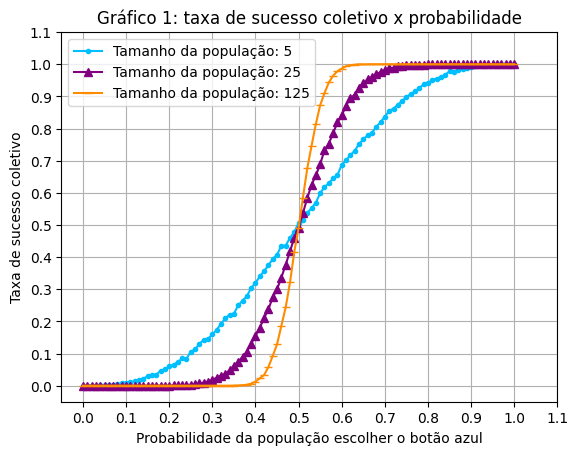

In [10]:
probabilidades_finais = [i/100 for i in range(101)]
lista_tamanhos = [5, 25, 125]
cores = ["deepskyblue", "purple", "darkorange"]
markers = [".", "^", "_"]

for i, tamanho in enumerate(lista_tamanhos):
    sucesso_coletivo, sobrevivencia = variacao_probabilidade(probabilidades_finais, tamanho)

    mpl.plot(
        probabilidades_finais,
        sucesso_coletivo,
        color=cores[i],
        marker=markers[i],
        label=f"Tamanho da população: {tamanho}",
    )

mpl.xlabel("Probabilidade da população escolher o botão azul")
mpl.ylabel("Taxa de sucesso coletivo")
mpl.title("Gráfico 1: taxa de sucesso coletivo x probabilidade")

mpl.legend()
mpl.grid()

mpl.xticks(np.arange(0, 1.2, 0.1))
mpl.yticks(np.arange(0, 1.2, 0.1))

mpl.show()

### 2.11 Plotando o gráfico de média de sobrevivência por probabilidade

Como para o gráfico anterior, foi concebida uma célula capaz de plotar um gráfico. Este representa a taxa de sobrevivência média pela probabilidade.

As mesmas listas `probabilidades_finais` e `tamanhos` foram usadas de base para o eixo de probabilidades e para as diferentes curvas de tamanhos da população.

Para cada tamanho de população, também foi chamada a função `variacao_probabilidade`, mas para esse gráfico foi utilizado apenas o retorno `sobrevivencia`. Esses dados foram então utilizados para construir as curvas do novo gráfico.

Assim como no anterior, foi utilizada uma lista de cores `cores` e de marcadores `markers` para melhor identificação das curvas no gráfico. Além disso, foram definidos os rótulos dos eixos, o título do gráfico e uma grade de referência, também com uso da biblioteca importada na primeira célula de código: `matplotlib.pyplot`. Os valores dos eixos foram novamente organizados com auxílio da biblioteca `numpy`, garantindo intervalos regulares e melhor visualização dos resultados. O gráfico final permite observar como a probabilidade individual impacta a taxa de sobrevivência da população de acordo com o seu tamanho.

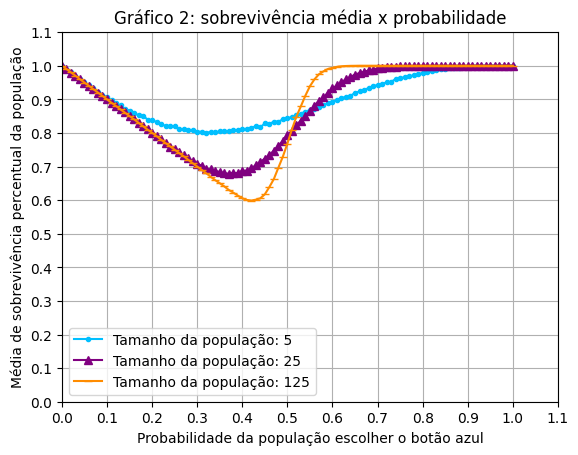

In [11]:
for i, tamanho in enumerate(lista_tamanhos):
    sucesso_coletivo, sobrevivencia = variacao_probabilidade(probabilidades_finais, tamanho)

    mpl.plot(
        probabilidades_finais,
        sobrevivencia,
        color=cores[i],
        marker=markers[i],
        label=f"Tamanho da população: {tamanho}",
    )

mpl.xlabel("Probabilidade da população escolher o botão azul")
mpl.ylabel("Média de sobrevivência percentual da população")
mpl.title("Gráfico 2: sobrevivência média x probabilidade")

mpl.legend()
mpl.grid()

mpl.xlim(0, 1.1)
mpl.ylim(0, 1.1)

mpl.xticks(np.arange(0, 1.2, 0.1))
mpl.yticks(np.arange(0, 1.2, 0.1))

mpl.show()

## 3. Resultados e discussão: gráficos

A partir dos gráficos, foi possível observar os comportamentos médios das populações para diferentes tamanhos e probabilidades.

No gráfico 1 `taxa de sucesso coletivo x probabilidade`, foi possível observar que para probabilidades baixas, a taxa de sucesso coletivo é mais próxima de zero, dentro do número de rodadas estipulado pela função `escala_simulacao` (1000). Isso ocorre porque, dada uma probabilidade pequena de escolha do botão azul para cada indivíduo, para que mais da metade deles escolha de fato o botão azul, as chances são muito poucas.

Além disso, há a componente populacional. Para o gráfico 1, ela altera a vertiginosidade da subida. Em populações diminutas, ela é mais suave, beirando a constância, porque o desvio da média é muito mais alto. Já em populações maiores, a taxa de sucesso permanece zero até probabilidades individuais próximas a 0.4, quando começa a haver consistentemente cenários em que há sucesso coletivo. Nota-se a existência de um ponto crítico fenomenológico para y = 0.5, quando a probabilidade é de exatamente 0.5 de que os indivíduos escolham o botão azul. A partir daí, a taxa de sucesso coletivo é consistentemente maior que 0.5, não importa para qual tamanho de população, até chegar a 1, o que ocorre mais abruptamente em populações maiores.

No gráfico 2 `sobrevivência média x probabilidade`, foi observado que para as probabilidades baixas, a taxa de sobrevivência é igual à proporção de pessoas que escolheram o botão vermelho, mais a taxa de sucesso coletivo. Então, para populações menores, o mínimo da sobrevivência média é maior, porque há mais cenários em probabilidades mais baixas em que há sucesso coletivo. O mínimo é atingido antes da taxa de sucesso coletivo começar a ser significativa.

Tais comportamentos podem ser descritos pela lei dos grandes números. Ela estabelece que, à medida que o número de observações independentes aumenta, a média dos resultados tende a se aproximar do valor esperado. No contexto do modelo, isso se traduz no fato de que, para populações maiores, a proporção de indivíduos que escolhem o botão azul tende a se aproximar da probabilidade individual atribuída a cada pessoa.

Consequentemente, em populações grandes, a fração de indivíduos que escolhe cada botão torna-se mais previsível, reduzindo o impacto das flutuações aleatórias. Isso explica por que as curvas associadas a populações maiores apresentam transições mais abruptas no gráfico 1 e maior suavidade no gráfico 2: o comportamento coletivo se torna menos sujeito a variações estocásticas e mais próximo do comportamento médio esperado.

Por outro lado, em populações pequenas, as flutuações em torno da média são mais significativas, o que permite que ocorram resultados que se afastam do valor esperado, como cenários de sucesso coletivo mesmo para probabilidades individuais baixas. Esse efeito explica a maior irregularidade observada nas curvas e os valores mais elevados de sobrevivência média nessas populações.

## 4. Interface

Na etapa final do projeto, foi desenvolvida uma interface interativa que permite a inserção manual dos participantes e a realização de escolhas individuais entre os botões azul e vermelho. Diferentemente da simulação probabilística, a interface possibilita que as decisões não sejam geradas aleatoriamente ou sejam a mesma para todo o conjunto populacional, mas sim determinadas individualmente por cada usuário.

A tela da interface foi montada com a utilização da biblioteca `Tkinter`, importada no começo do código. Ela justamente permite a criação de uma nova janela, em que se pode adicionar textos com objetos do tipo classe (`widgets`). `tk.Label`, `tk.Entry` e `tk.Button` foram os utilizados.

Para cada novo participante, é solicitado que seja inserido um nome, e aperte um botão `entrar`. Na sequência, o indivíduo pode escolher entre os dois botões disponíveis: `azul` e `vermelho`. Essas escolhas são registradas e armazenadas separadamente em listas, permitindo a posterior avaliação dos resultados com base no mesmo critério adotado na simulação. Após cada escolha, o sistema oferece a possibilidade de adicionar um novo participante ou de encerrar a rodada e analisar o resultado.

Ao final, os resultados são apresentados, indicando os sobreviventes e os eliminados com base nas escolhas realizadas. A interface também permite reiniciar o processo, possibilitando múltiplas rodadas com diferentes grupos de participantes.

Essa abordagem complementa a análise probabilística realizada anteriormente, permitindo comparar o comportamento de populações simuladas com decisões reais tomadas pelos usuários, evidenciando, na prática, os efeitos coletivos das escolhas individuais.

### 4.1 Criando variáveis globais

Para as funções da interface, foi necessário criar antes variáveis globais: as listas vazias `azul` e `vermelho`, para adicionar os usuários que votam correspondentemente aos botões dessas cores, e que é o retorno final, e as variáveis para o campo de entrada em que o jogador insere o nome `entrada_nome`, e para armazenar o nome do jogador, que depois será adicionado à lista `azul` ou `vermelha`: `jogador_atual`. As duas últimas foram definidas como `None` inicialmente, e depois terão valores atribuídos dentro das funções.

In [12]:
azul = []
vermelho = []

entrada_nome = None
jogador_atual = None

### 4.2 Definindo funções da tela final

Nesta etapa, foram implementadas funções responsáveis pela exibição dos resultados finais do jogo.

A função `tela_pos_escolha` é apresentar uma tela intermediária após cada decisão individual. Nela, o sistema confirma que a escolha foi registrada e oferece duas opções (como botões): permitir a entrada de um novo participante ou prosseguir para os resultados. Dessa forma, a interface possibilita a construção iterativa de uma população cujas decisões são inseridas manualmente.

Já a função `resultado` é responsável por avaliar as escolhas realizadas pelos participantes e apresentar o resultado final. Para isso, o sistema calcula o total de indivíduos e verifica se a maioria escolheu o botão azul. Caso essa condição seja satisfeita, todos os participantes sobrevivem; caso contrário, apenas aqueles que escolheram o botão vermelho são considerados sobreviventes.

Os resultados são exibidos na última atualização da tela, indicando os sobreviventes e os eliminados. Além disso, é disponibilizado um botão que permite reiniciar o processo, possibilitando novas rodadas com diferentes conjuntos de participantes.

In [13]:
def resultado():
    """
    Calcula e exibe o resultado coletivo a partir das escolhas registradas.

    A função utiliza as listas globais `azul` e `vermelho`, que armazenam
    os participantes que escolheram cada botão. Com base nessas listas,
    verifica se houve sucesso coletivo (maioria escolheu azul) e determina
    quais indivíduos sobreviveram.

    A interface é limpa e atualizada para exibir:
        - uma mensagem com o resultado final (Todos sobreviveram!), se a
        maioria tiver apertado o botão azul;
        - a lista de sobreviventes e eliminados (se não houver
        sucesso coletivo);
        - um botão para reiniciar o jogo.

    Entrada:
        Nenhuma (usa variáveis globais).

    Retorno:
        None.
    """

    for widget in bloco.winfo_children():
        widget.destroy()

    total = len(azul) + len(vermelho)

    if len(azul) > total/2:
        texto = "Todos sobreviveram!"
    else:
        sobreviventes = ", ".join(vermelho)
        eliminados = ", ".join(azul)

        texto = "Sobreviventes: " + sobreviventes + "\n"
        texto += "Eliminados: " + eliminados

    resultado_final = tk.Label(
        bloco,
        text=texto,
        font=("Times New Roman", 16),
        fg="darkblue",
        bg="beige",
        justify="center"
    )
    reiniciar_jogo = tk.Button(
        bloco,
        bg="darkgreen",
        text="Reiniciar o jogo",
        font=("Times New Roman", 12),
        fg="white",
        width=10,
        command=reiniciar
    )

    resultado_final.pack(pady=(0, 0))
    reiniciar_jogo.pack(pady=(20, 20))
        

def tela_pos_escolha():
    """
    Exibe uma tela intermediária após o registro de uma escolha individual.

    A função limpa a interface atual e apresenta uma confirmação de que
    a escolha foi registrada. Em seguida, oferece duas opções ao usuário:
        - adicionar um novo participante (voltar à tela inicial);
        - finalizar a rodada e calcular o resultado coletivo.

    Entrada:
        Nenhuma (usa variáveis globais).

    Retorno:
        None.
    """
    
    for widget in bloco.winfo_children():
        widget.destroy()

    registro_escolha = tk.Label(
        bloco,
        text="Escolha registrada!",
        font=("Times New Roman", 16),
        fg="darkblue",
        bg="beige"
    )
    botao_seguir = tk.Button(
        bloco,
        bg="darkblue",
        text="Próximo jogador",
        font=("Times New Roman", 16),
        fg="white",
        width=15,
        command=criar_tela_inicial
    )
    botao_submeter = tk.Button(
        bloco,
        bg="darkgreen",
        text="Submeter resultados",
        font=("Times New Roman", 16),
        fg="white",
        width=15,
        command=resultado
    )
    frase = tk.Label(
        bloco,
        text="Está preparado para saber se você sobreviveu?",
        font=("Times New Roman", 12),
        fg="darkblue",
        bg="beige"
    )

    registro_escolha.pack(pady=(0, 0))
    botao_seguir.pack(pady=(50, 5))
    botao_submeter.pack(pady=(0, 0))
    frase.pack(pady=(50, 20))

### 4.3 Definindo funções de escolha

Foram implementadas funções para registrar as escolhas individuais dos participantes e controlar o fluxo da aplicação.

As funções `escolher_azul` e `escolher_vermelho` têm como objetivo registrar a decisão de cada participante. A partir da variável `jogador_atual`, que armazena o nome do usuário ativo, cada função adiciona o indivíduo à respectiva lista (`azul` ou `vermelho`). Após o registro da escolha, a atualizada para `tela_pos_escolha`.

Já a função `reiniciar` é responsável por redefinir o estado do jogo, após o final, removendo todas as escolhas previamente registradas. Para isso, as listas `azul` e `vermelho` são esvaziadas, e a interface retorna à tela inicial, possibilitando o início de uma nova rodada com um novo conjunto de participantes.

In [14]:
def escolher_azul():
    """
    A função adiciona a variável jogador_atual à lista azul quando o usuário 
    clica no botão azul, chamando a função tela_pos_escolha.

    Entrada:
        Nenhuma (usa variáveis globais).

    Retorno:
        None.
    """

    azul.append(jogador_atual)

    tela_pos_escolha()

def escolher_vermelho():
    """
    A função adiciona a variável jogador_atual à lista vermelho quando o
    usuário clica no botão vermelho, chamando a função tela_pos_escolha.

    Entrada:
        Nenhuma (usa variáveis globais).

    Retorno:
        None.
    """

    vermelho.append(jogador_atual)

    tela_pos_escolha()

def reiniciar():
    """
    A função limpa as listas azul e vermelho, removendo todas as escolhas 
    registradas, e retorna à tela inicial chamando a função criar_tela_inicial.

    Entrada:
        Nenhuma.

    Retorno:
        None.
    """

    azul.clear()
    vermelho.clear()

    criar_tela_inicial()

### 4.4 Definindo funções do começo da interface

Nesta célula, foram implementadas funções para criação da tela inicial da interface e pelo retorno a esse estado inicial durante a execução do jogo.

A função `criar_tela_inicial` tem como objetivo construir a interface principal do sistema, na qual o usuário é convidado a inserir seu nome antes de participar do jogo. Para isso, são criados elementos visuais como título, rótulos de instrução, campo de entrada de texto e botão de confirmação. Além disso, um texto explicativo apresenta as regras do dilema, garantindo que o usuário compreenda o funcionamento do sistema antes de realizar sua escolha.

Ao ser acionado, o botão "Entrar" chama a função `entrar`, que dá continuidade ao fluxo da aplicação. A função também utiliza a variável global `entrada_nome` para permitir o acesso ao valor inserido pelo usuário em outras etapas do programa.

Já a função `voltar` é responsável por restaurar a tela inicial a partir de outros estados da interface. Para isso, realiza a limpeza dos elementos visuais atuais e chama novamente a função `criar_tela_inicial`, permitindo que o fluxo do jogo seja reiniciado ou ajustado conforme necessário.

Essas funções estabelecem o ponto de partida da interação com o sistema, organizando a interface inicial e permitindo a navegação entre diferentes etapas da aplicação.

In [15]:
def criar_tela_inicial():
    """
    A função cria a tela inicial da interface do jogo.

    Limpa todos os elementos da interface atual e constrói uma nova tela
    contendo título, instruções, campo de entrada de nome e botão de acesso.
    O nome inserido é armazenado na variável global entrada_nome para uso 
    posterior.

    Entrada:
        Nenhuma (usa variáveis globais).

    Retorno:
        None.
    """

    global entrada_nome

    for widget in bloco.winfo_children():
        widget.destroy()
    
    titulo = tk.Label(
        bloco,
        text="DILEMA DO BOTÃO",
        font=("Times New Roman", 24, "bold"),
        fg="darkblue",
        bg="beige"
    )
    nome = tk.Label(
        bloco,
        text="Digite seu nome",
        font=("Times New Roman", 16),
        fg="darkblue",
        bg="beige"
    )
    entrada_nome = tk.Entry(
        bloco,
        fg="black",
        font=("Times New Roman", 12),
        bg="white",
        width=20,
        justify="center"
    )
    botao_entrar = tk.Button(
        bloco,
        bg="darkred",
        text="Entrar",
        font=("Times New Roman", 16),
        fg="white",
        width=10,
        command=entrar
    )
    texto_explicativo = tk.Label(
        bloco,
        text="""Neste jogo, cada participante escolhe entre dois botões: azul
    ou vermelho. Se a maioria escolher o azul, todos sobrevivem; 
    senão, apenas quem escolher o vermelho permanece vivo. 
    Será que você vai sobreviver?""",
        font=("Times New Roman", 12),
        fg="darkblue",
        bg="beige",
        justify="center"
    )

    titulo.pack(pady=(0, 50))
    nome.pack(pady=(0, 0))
    entrada_nome.pack(pady=(0, 0))
    botao_entrar.pack(pady=(50, 0))
    texto_explicativo.pack(pady=(50, 20))

def voltar():
    """
    A função retorna à tela inicial da interface.

    Limpa os elementos visuais atuais e chama a função criar_tela_inicial,
    restaurando o estado inicial do sistema.

    Entrada:
        Nenhuma.

    Retorno:
        None.
    """

    for widget in bloco.winfo_children():
        widget.destroy()
    
    criar_tela_inicial()

### 4.5 Definindo a função entrar

Esta célula, foi implementada a função `entrar`, responsável por dar continuidade ao fluxo do jogo após a inserção do nome do participante.

A função tem como objetivo capturar o nome inserido pelo usuário no campo de entrada (`entrada_nome`) e armazená-lo na variável global `jogador_atual`, que identifica o participante ativo. Em seguida, a interface é limpa para dar lugar a uma nova tela, na qual o jogador pode realizar sua escolha.

Na nova interface, são exibidos elementos que indicam o nome do jogador atual e apresentam as opções de escolha entre os botões azul e vermelho. Cada botão está associado a uma função específica (`escolher_azul` ou `escolher_vermelho`), responsável por registrar a decisão do participante.

Além disso, é incluído um botão de retorno (`voltar`), que permite ao usuário retornar à tela inicial, caso deseje.

Essa função estabelece a transição entre a entrada de dados e a tomada de decisão individual, conectando a participação do usuário à lógica central do jogo.

In [16]:
def entrar():
    """
    A função captura o nome inserido pelo usuário e exibe a tela de escolha.

    Obtém o valor do campo de entrada (entrada_nome) e armazena na variável
    global jogador_atual, identificando o participante ativo. Em seguida,
    limpa a interface atual e constrói a tela onde o jogador pode escolher
    entre os botões azul e vermelho.

    A interface inclui:
        - identificação do jogador atual;
        - botões de escolha (azul e vermelho);
        - botão de retorno à tela inicial.

    Entrada:
        Nenhuma (usa variáveis globais).

    Retorno:
        None.
    """
    global jogador_atual
    
    nome = entrada_nome.get()
    jogador_atual = nome

    for widget in bloco.winfo_children():
        widget.destroy()

    
    jogador = tk.Label(
        bloco,
        text=f"JOGADOR: {nome}",
        font=("Times New Roman", 16, "bold"),
        fg="darkblue",
        bg="beige"
    )

    escolha = tk.Label(
        bloco,
        text="Escolha o seu botão:",
        font=("Times New Roman", 16),
        fg="darkblue",
        bg="beige"
    )
    botao_azul = tk.Button(
        bloco,
        bg="darkblue",
        text="AZUL",
        font=("Times New Roman", 16),
        fg="white",
        width=10,
        command=escolher_azul
    )
    botao_vermelho = tk.Button(
        bloco,
        bg="darkred",
        text="VERMELHO",
        font=("Times New Roman", 16),
        fg="white",
        width=10,
        command=escolher_vermelho
    )
    texto_engracadinho_batalha_cassar = tk.Label(
        bloco,
        text="CUIDADO!!! É perigoso seguir sozinho!",
        font=("Times New Roman", 12),
        fg="darkblue",
        bg="beige",
        justify="center"
    )
    botao_voltar = tk.Button(
        bloco,
        bg="brown",
        text="Voltar",
        font=("Times New Roman", 10),
        fg="white",
        width=5,
        command=voltar
    )

    jogador.pack(pady=(0, 50))
    escolha.pack(pady=(0, 10))
    botao_azul.pack(pady=(0, 5))
    botao_vermelho.pack(pady=(0, 0))
    texto_engracadinho_batalha_cassar.pack(pady=(50, 0))
    botao_voltar.pack(pady=(10, 20))

### 4.6 Inicializando de fato a interface

Nesta célula, são definidos os elementos principais responsáveis pela criação e execução da interface gráfica do sistema.

Inicialmente, é criada a janela principal da aplicação (`root`), que funciona como a base para todos os componentes visuais da interface. Em seguida, são definidos com funções embutidas da biblioteca `Tkinter`: título, dimensões da janela e cor de fundo.

Posteriormente, é criado um frame (`bloco`), que atua como área central onde os elementos gráficos são inseridos dinamicamente ao longo da execução do programa. Esse frame é configurado para ocupar o espaço disponível na janela, permitindo uma organização mais flexível da interface, sem a necessidade de criar várias tela, apenas atualizando uma única.

A função `criar_tela_inicial` é então chamada, estabelecendo o primeiro estado visível da aplicação, no qual o usuário pode iniciar a interação com o sistema.

Por fim, é iniciado o loop principal da interface (`mainloop`), que mantém a janela ativa e permite o processamento contínuo das interações do usuário, como cliques e entradas de texto.

In [ ]:
root = tk.Tk()

root.title("Dilema do botão")

root.geometry("600x600+50+50")

root.configure(bg="beige")

bloco = tk.Frame(root, bg="beige")

bloco.pack(expand=True)
criar_tela_inicial()
root.mainloop()

## 5. Conclusão

A partir de tudo o que foi realizado no projeto, conclui-se que ele está de acordo com a proposta, tendo os conceitos da disciplina sido amplamente abordados: o uso fluente de funções embutidas de Python, criação de variáveis, laços de repetição, definição de funções próprias, uso de repositório git e boas práticas de programação.

Ademais, para além do que foi apresentado na disciplina, procurou-se desafios que pudessem expandir o rol de habilidades, para isso tendo sido aprendida a plotação de gráficos e criação de interface, o que permitiu também aprofundar e integrar os conceitos da disciplina.

Considera-se o resultado satisfatório diante da dificuldade esperada e do nível de programação desenvolvedor. No entanto, há espaço para melhora dentro do próprio projeto, como otimização das funções, expansão das análises dos gráficos e integração com Teoria de Jogos e interface mais completa, com espaço para mais versões do dilema.